# Total overkill
<img align=right src = "https://i.discogs.com/KNjsAty699ddIsz5aTiiNoUZm0FjdsGxo4xkvoTFLMQ/rs:fit/g:sm/q:90/h:600/w:600/czM6Ly9kaXNjb2dz/LWRhdGFiYXNlLWlt/YWdlcy9SLTE5MzM3/ODEtMTMyMDE3NTc1/Ny5qcGVn.jpeg" width="250">
This is for an ML basics group I lead... A lot of what's done here is not needed/useful for this little contest, but the point is to show clear examples of many common ML techniques for tabular data.

# Techniques in this notebook:
- √ Feature engineering
    - √ Explode column column into three columns
    - √ Target (mean) encode + fill any other nan
    - √ One hot encoding
- √ Adversarial validation
- √ 5 fold cross validation
- Two models used
    - √ TabPFN
    - √ LightGBM - hyper params optimized!
- √ Weighted ensemble of models
-  √  Submission to the contest

## Leader board
- speed run =  0.74701 (v1 of this)
- Just with target encodes and LightGBM = 0.79635
- Got worse with everything added after that!!! Down to 0.78115
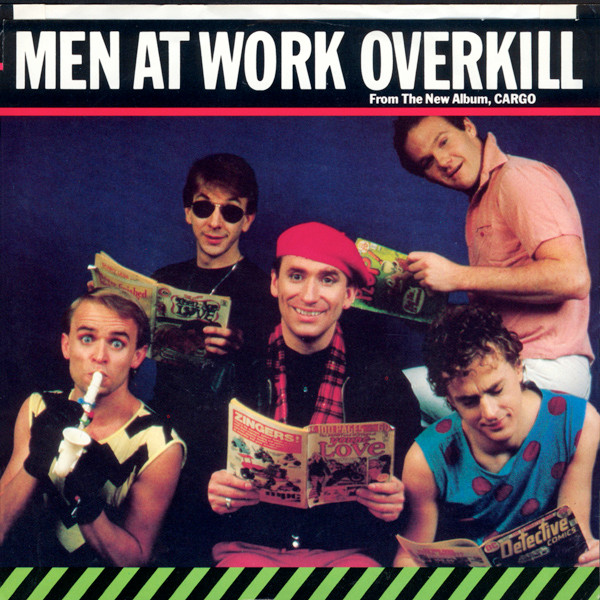

In [1]:
import utility as utl 
# This is my little utility script. I collect useful functions that I've made 
# or found while kaggling that I use frequently.
# https://www.kaggle.com/code/beezus666/utility

import lightgbm as lgb
import numpy as np
import pandas as pd 
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import optuna
IS_INTERACTIVE = os.environ['KAGGLE_KERNEL_RUN_TYPE'] == 'Interactive'

In [2]:
# read in csvs and create DFs
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:        
        print(os.path.join(dirname, filename))
        no_ext = f'{os.path.splitext(filename)[0]}_df'
        no_ext = no_ext.replace(" ", "_")
        no_ext = no_ext.replace("-", "_")
        globals()[no_ext] = pd.read_csv(os.path.join(dirname, filename))

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [3]:
dfs = %who_ls DataFrame
for df in dfs: 
    utl.reduce_mem_usage(globals()[df], True)
    utl.df_info(globals()[df], df)

Mem. usage decreased to  0.04 Mb (0.0% reduction)
=== sample_submission_df ===
Shape: (4277, 2)
Missing Values: 0 total missing datapoints.
Columns: ['PassengerId', 'Transported'] 



,PassengerId,Transported
4272,9266_02,False
4273,9269_01,False
4274,9271_01,False
4275,9273_01,False
4276,9277_01,False




Mem. usage decreased to  0.28 Mb (34.6% reduction)
=== test_df ===
Shape: (4277, 13)
Missing Values: 1117 total missing datapoints.
Columns: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name'] 



,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale
4276,9277_01,Earth,True,G/1498/S,PSO J318.5-22,43.0,False,0.0,0.0,0.0,0.0,0.0,Lilace Leonzaley




Mem. usage decreased to  0.57 Mb (34.3% reduction)
=== train_df ===
Shape: (8693, 14)
Missing Values: 2324 total missing datapoints.
Columns: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported'] 



,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6820.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3236.0,Celeon Hontichre,False
8692,9280_02,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,0.0,12.0,Propsh Hontichre,True


# Feature engineering
The below functions process the given CSVs into training and test sets.

It's a good idea to write stuff like this as functions because much of it needs to be done the same way in both training and test. Little functions like below let you stay organized, and then write code that's more readable and consistent.

In [4]:
def process_df(df): 
    """
    This function will do all feature engineering that is done in both 
    """
    if 'Name' in df: df = df.drop(['Name'], axis=1)
    
    # Split the 'Cabin' column at the slashes and expand it into a DataFrame
    if 'Cabin' in df: #running it twice it wont be there...
        cabin_df = df['Cabin'].str.split('/', expand=True)
        cabin_df.columns = ['Cabin1', 'Cabin2', 'Cabin3']
        if 'Cabin2' in cabin_df: cabin_df = cabin_df.drop(['Cabin2'], axis=1)
        #df['Cabin2'].fillna(0, inplace=True)
        #df['Cabin2'] = pd.to_numeric(df['Cabin2'], errors='coerce')
        
        
        df = pd.concat([df, cabin_df], axis=1)    
        df.drop('Cabin', axis=1, inplace=True)
    
    # deal with nan's
    object_columns = utl.get_columns_by_type(df,'object')
    if 'PassengerId' in df: object_columns.remove('PassengerId')
    for obj_col in object_columns:
        
        df[obj_col] = df[obj_col].fillna('missing') # 'missing' as new category to use for target encode
        df[obj_col] = df[obj_col].astype(str)
    
    float16_cols = utl.get_columns_by_type(df,'float16')
    for fl16_col in float16_cols:
        average = df[fl16_col].mean()
        df[fl16_col] = df[fl16_col].fillna(average)
    
    float64_cols = utl.get_columns_by_type(df,'float64')
    for fl64_col in float64_cols:
        average = df[fl64_col].mean()
        df[fl64_col] = df[fl64_col].fillna(average)
    
    return df


def target_encode(df):
    object_columns = utl.get_columns_by_type(df,'object')
    if 'PassengerId' in df: object_columns.remove('PassengerId')
    for obj_col in object_columns:
        df[obj_col+'_encoded'] = df.groupby(obj_col)['Transported'].transform('mean')
        #df.drop(obj_col, axis=1, inplace=True) #can't drop until put in test_df
    return df

# Dataframe processing - train and test
The below code uses the above functions to process train and test. It does feature engineering and splits data.

In [5]:
##########
#Train 
##########
train_df = process_df(train_df)
train_df, no_ohe_cols = utl.ohe_categorical(train_df, utl.get_columns_by_type(train_df,'object'))
train_df = target_encode(train_df)    

if 'PassengerId' in train_df: Ids_pop = train_df.pop('PassengerId') # save ids



utl.df_info(train_df, "train_df")

=== train_df ===
Shape: (8693, 45)
Missing Values: 0 total missing datapoints.
Columns: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'HomePlanet_missing', 'HomePlanet', 'CryoSleep_False', 'CryoSleep_True', 'CryoSleep_missing', 'CryoSleep', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Destination_missing', 'Destination', 'VIP_False', 'VIP_True', 'VIP_missing', 'VIP', 'Cabin1_A', 'Cabin1_B', 'Cabin1_C', 'Cabin1_D', 'Cabin1_E', 'Cabin1_F', 'Cabin1_G', 'Cabin1_T', 'Cabin1_missing', 'Cabin1', 'Cabin3_P', 'Cabin3_S', 'Cabin3_missing', 'Cabin3', 'HomePlanet_encoded', 'CryoSleep_encoded', 'Destination_encoded', 'VIP_encoded', 'Cabin1_encoded', 'Cabin3_encoded'] 



,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,...,Cabin3_P,Cabin3_S,Cabin3_missing,Cabin3,HomePlanet_encoded,CryoSleep_encoded,Destination_encoded,VIP_encoded,Cabin1_encoded,Cabin3_encoded
8688,41.0,0.0,6820.0,0.0,1643.0,74.0,False,0,1,0,...,1,0,0,P,0.658846,0.328921,0.610000,0.381910,0.496094,0.451260
8689,18.0,0.0,0.0,0.0,0.0,0.0,False,1,0,0,...,0,1,0,S,0.423946,0.817583,0.503769,0.506332,0.516217,0.555037
8690,26.0,0.0,0.0,1872.0,1.0,0.0,True,1,0,0,...,0,1,0,S,0.423946,0.328921,0.471175,0.506332,0.516217,0.555037
8691,32.0,0.0,1049.0,0.0,353.0,3236.0,False,0,1,0,...,0,1,0,S,0.658846,0.328921,0.610000,0.506332,0.357306,0.555037
8692,44.0,126.0,4688.0,0.0,0.0,12.0,True,0,1,0,...,0,1,0,S,0.658846,0.328921,0.471175,0.506332,0.357306,0.555037


In [6]:
##########
#Test
##########
test_df = process_df(test_df)
test_df, test_no_ohe_cols = utl.ohe_categorical(test_df, utl.get_columns_by_type(test_df,'object'))
#train_processed_df = pd.read_csv('/kaggle/working/train_processed.csv') #over kill to save...
utl.df_info(test_df, "test_df")

=== test_df ===
Shape: (4277, 39)
Missing Values: 0 total missing datapoints.
Columns: ['PassengerId', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'HomePlanet_missing', 'HomePlanet', 'CryoSleep_False', 'CryoSleep_True', 'CryoSleep_missing', 'CryoSleep', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Destination_missing', 'Destination', 'VIP_False', 'VIP_True', 'VIP_missing', 'VIP', 'Cabin1_A', 'Cabin1_B', 'Cabin1_C', 'Cabin1_D', 'Cabin1_E', 'Cabin1_F', 'Cabin1_G', 'Cabin1_T', 'Cabin1_missing', 'Cabin1', 'Cabin3_P', 'Cabin3_S', 'Cabin3_missing', 'Cabin3'] 



,PassengerId,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,...,Cabin1_E,Cabin1_F,Cabin1_G,Cabin1_T,Cabin1_missing,Cabin1,Cabin3_P,Cabin3_S,Cabin3_missing,Cabin3
4272,9266_02,34.0,0.0,0.0,0.0,0.0,0.0,1,0,0,...,0,0,1,0,0,G,0,1,0,S
4273,9269_01,42.0,0.0,847.0,17.0,10.0,144.0,1,0,0,...,0,0,0,0,1,missing,0,0,1,missing
4274,9271_01,inf,0.0,0.0,0.0,0.0,0.0,0,0,1,...,0,0,0,0,0,D,1,0,0,P
4275,9273_01,inf,0.0,2680.0,0.0,0.0,523.0,0,1,0,...,0,0,0,0,0,D,1,0,0,P
4276,9277_01,43.0,0.0,0.0,0.0,0.0,0.0,1,0,0,...,0,0,1,0,0,G,0,1,0,S


In [7]:
# taking target encodes from train_df and putting them in test_df
for column in train_df.columns:
    if column.endswith('_encoded'):
        column_name = column.split('_')[0]  # Extract the original column name            
        mapping = train_df.groupby(column_name)[column].first().to_dict()
        test_df[column] = test_df[column_name].map(mapping)

if 'PassengerId' in test_df: Ids_test_pop = test_df.pop('PassengerId') # save ids


utl.df_info(test_df, "test_df")

=== test_df ===
Shape: (4277, 44)
Missing Values: 0 total missing datapoints.
Columns: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'HomePlanet_missing', 'HomePlanet', 'CryoSleep_False', 'CryoSleep_True', 'CryoSleep_missing', 'CryoSleep', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Destination_missing', 'Destination', 'VIP_False', 'VIP_True', 'VIP_missing', 'VIP', 'Cabin1_A', 'Cabin1_B', 'Cabin1_C', 'Cabin1_D', 'Cabin1_E', 'Cabin1_F', 'Cabin1_G', 'Cabin1_T', 'Cabin1_missing', 'Cabin1', 'Cabin3_P', 'Cabin3_S', 'Cabin3_missing', 'Cabin3', 'HomePlanet_encoded', 'CryoSleep_encoded', 'Destination_encoded', 'VIP_encoded', 'Cabin1_encoded', 'Cabin3_encoded'] 



,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_missing,...,Cabin3_P,Cabin3_S,Cabin3_missing,Cabin3,HomePlanet_encoded,CryoSleep_encoded,Destination_encoded,VIP_encoded,Cabin1_encoded,Cabin3_encoded
4272,34.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,...,0,1,0,S,0.423946,0.817583,0.471175,0.506332,0.516217,0.555037
4273,42.0,0.0,847.0,17.0,10.0,144.0,1,0,0,0,...,0,0,1,missing,0.423946,0.328921,0.471175,0.506332,0.502513,0.502513
4274,inf,0.0,0.0,0.0,0.0,0.0,0,0,1,0,...,1,0,0,P,0.523024,0.817583,0.610000,0.506332,0.433054,0.451260
4275,inf,0.0,2680.0,0.0,0.0,523.0,0,1,0,0,...,1,0,0,P,0.658846,0.328921,0.505495,0.506332,0.433054,0.451260
4276,43.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,...,0,1,0,S,0.423946,0.817583,0.503769,0.506332,0.516217,0.555037


In [8]:
for col in utl.get_columns_by_type(train_df, 'object'):
    train_df.drop(col, axis=1, inplace=True)
    test_df.drop(col, axis=1, inplace=True)

utl.df_info(train_df, "train_df")
    

=== train_df ===
Shape: (8693, 39)
Missing Values: 0 total missing datapoints.
Columns: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'HomePlanet_missing', 'CryoSleep_False', 'CryoSleep_True', 'CryoSleep_missing', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Destination_missing', 'VIP_False', 'VIP_True', 'VIP_missing', 'Cabin1_A', 'Cabin1_B', 'Cabin1_C', 'Cabin1_D', 'Cabin1_E', 'Cabin1_F', 'Cabin1_G', 'Cabin1_T', 'Cabin1_missing', 'Cabin3_P', 'Cabin3_S', 'Cabin3_missing', 'HomePlanet_encoded', 'CryoSleep_encoded', 'Destination_encoded', 'VIP_encoded', 'Cabin1_encoded', 'Cabin3_encoded'] 



,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,...,Cabin1_missing,Cabin3_P,Cabin3_S,Cabin3_missing,HomePlanet_encoded,CryoSleep_encoded,Destination_encoded,VIP_encoded,Cabin1_encoded,Cabin3_encoded
8688,41.0,0.0,6820.0,0.0,1643.0,74.0,False,0,1,0,...,0,1,0,0,0.658846,0.328921,0.610000,0.381910,0.496094,0.451260
8689,18.0,0.0,0.0,0.0,0.0,0.0,False,1,0,0,...,0,0,1,0,0.423946,0.817583,0.503769,0.506332,0.516217,0.555037
8690,26.0,0.0,0.0,1872.0,1.0,0.0,True,1,0,0,...,0,0,1,0,0.423946,0.328921,0.471175,0.506332,0.516217,0.555037
8691,32.0,0.0,1049.0,0.0,353.0,3236.0,False,0,1,0,...,0,0,1,0,0.658846,0.328921,0.610000,0.506332,0.357306,0.555037
8692,44.0,126.0,4688.0,0.0,0.0,12.0,True,0,1,0,...,0,0,1,0,0.658846,0.328921,0.471175,0.506332,0.357306,0.555037


In [9]:
# after processing let's see what we have and are about to train on
dfs = %who_ls DataFrame
for df in dfs: 
    utl.reduce_mem_usage(globals()[df], True)
    utl.df_info(globals()[df], df)

Mem. usage decreased to  0.04 Mb (0.0% reduction)
=== sample_submission_df ===
Shape: (4277, 2)
Missing Values: 0 total missing datapoints.
Columns: ['PassengerId', 'Transported'] 



,PassengerId,Transported
4272,9266_02,False
4273,9269_01,False
4274,9271_01,False
4275,9273_01,False
4276,9277_01,False




Mem. usage decreased to  0.35 Mb (0.0% reduction)
=== test_df ===
Shape: (4277, 38)
Missing Values: 0 total missing datapoints.
Columns: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'HomePlanet_missing', 'CryoSleep_False', 'CryoSleep_True', 'CryoSleep_missing', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Destination_missing', 'VIP_False', 'VIP_True', 'VIP_missing', 'Cabin1_A', 'Cabin1_B', 'Cabin1_C', 'Cabin1_D', 'Cabin1_E', 'Cabin1_F', 'Cabin1_G', 'Cabin1_T', 'Cabin1_missing', 'Cabin3_P', 'Cabin3_S', 'Cabin3_missing', 'HomePlanet_encoded', 'CryoSleep_encoded', 'Destination_encoded', 'VIP_encoded', 'Cabin1_encoded', 'Cabin3_encoded'] 



,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_missing,...,Cabin1_missing,Cabin3_P,Cabin3_S,Cabin3_missing,HomePlanet_encoded,CryoSleep_encoded,Destination_encoded,VIP_encoded,Cabin1_encoded,Cabin3_encoded
4272,34.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,...,0,0,1,0,0.423828,0.817383,0.471191,0.506348,0.516113,0.555176
4273,42.0,0.0,847.0,17.0,10.0,144.0,1,0,0,0,...,1,0,0,1,0.423828,0.328857,0.471191,0.506348,0.502441,0.502441
4274,inf,0.0,0.0,0.0,0.0,0.0,0,0,1,0,...,0,1,0,0,0.522949,0.817383,0.609863,0.506348,0.433105,0.451172
4275,inf,0.0,2680.0,0.0,0.0,523.0,0,1,0,0,...,0,1,0,0,0.658691,0.328857,0.505371,0.506348,0.433105,0.451172
4276,43.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,...,0,0,1,0,0.423828,0.817383,0.503906,0.506348,0.516113,0.555176




Mem. usage decreased to  0.72 Mb (0.0% reduction)
=== train_df ===
Shape: (8693, 39)
Missing Values: 0 total missing datapoints.
Columns: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'HomePlanet_missing', 'CryoSleep_False', 'CryoSleep_True', 'CryoSleep_missing', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Destination_missing', 'VIP_False', 'VIP_True', 'VIP_missing', 'Cabin1_A', 'Cabin1_B', 'Cabin1_C', 'Cabin1_D', 'Cabin1_E', 'Cabin1_F', 'Cabin1_G', 'Cabin1_T', 'Cabin1_missing', 'Cabin3_P', 'Cabin3_S', 'Cabin3_missing', 'HomePlanet_encoded', 'CryoSleep_encoded', 'Destination_encoded', 'VIP_encoded', 'Cabin1_encoded', 'Cabin3_encoded'] 



,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,...,Cabin1_missing,Cabin3_P,Cabin3_S,Cabin3_missing,HomePlanet_encoded,CryoSleep_encoded,Destination_encoded,VIP_encoded,Cabin1_encoded,Cabin3_encoded
8688,41.0,0.0,6820.0,0.0,1643.0,74.0,False,0,1,0,...,0,1,0,0,0.658691,0.328857,0.609863,0.381836,0.496094,0.451172
8689,18.0,0.0,0.0,0.0,0.0,0.0,False,1,0,0,...,0,0,1,0,0.423828,0.817383,0.503906,0.506348,0.516113,0.555176
8690,26.0,0.0,0.0,1872.0,1.0,0.0,True,1,0,0,...,0,0,1,0,0.423828,0.328857,0.471191,0.506348,0.516113,0.555176
8691,32.0,0.0,1049.0,0.0,353.0,3236.0,False,0,1,0,...,0,0,1,0,0.658691,0.328857,0.609863,0.506348,0.357422,0.555176
8692,44.0,126.0,4688.0,0.0,0.0,12.0,True,0,1,0,...,0,0,1,0,0.658691,0.328857,0.471191,0.506348,0.357422,0.555176


# Adversarial validation
## Basic concept 
(As per ChatGPT)
Adversarial Validation is a technique used in machine learning to assess the similarity between two datasets, typically the training and validation sets. It is particularly useful when we suspect that the validation set may differ significantly from the test set or contains data leakage.

Essentially we're looking to see if a model can tell between the training and test sets. If it can we will then remove features from the model.

## Overkill for this... 
As you'll see below, the AUC score here is very close to 0.5 which means no better than random. Therefore we don't need to remove any features.

I probably could have guessed that because this is a simple exercise, but hopefully this is a useful example on how to do this in the future.

For example this technique was used heavily in this competition by many gold medal winning teams: https://www.kaggle.com/competitions/amex-default-prediction/overview

In [10]:
################################
# Aversarial validation
################################


train_df['is_train'] = 0
test_df['is_train'] = 1

combined_df = pd.concat([train_df.drop(columns=['Transported']), test_df], ignore_index=True)
adversarial_X = combined_df.drop(columns=['is_train'])
adversarial_y = combined_df['is_train']

utl.df_info(adversarial_X, "adversarial_X")

=== adversarial_X ===
Shape: (12970, 38)
Missing Values: 0 total missing datapoints.
Columns: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'HomePlanet_missing', 'CryoSleep_False', 'CryoSleep_True', 'CryoSleep_missing', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Destination_missing', 'VIP_False', 'VIP_True', 'VIP_missing', 'Cabin1_A', 'Cabin1_B', 'Cabin1_C', 'Cabin1_D', 'Cabin1_E', 'Cabin1_F', 'Cabin1_G', 'Cabin1_T', 'Cabin1_missing', 'Cabin3_P', 'Cabin3_S', 'Cabin3_missing', 'HomePlanet_encoded', 'CryoSleep_encoded', 'Destination_encoded', 'VIP_encoded', 'Cabin1_encoded', 'Cabin3_encoded'] 



,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_missing,...,Cabin1_missing,Cabin3_P,Cabin3_S,Cabin3_missing,HomePlanet_encoded,CryoSleep_encoded,Destination_encoded,VIP_encoded,Cabin1_encoded,Cabin3_encoded
12965,34.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,...,0,0,1,0,0.423828,0.817383,0.471191,0.506348,0.516113,0.555176
12966,42.0,0.0,847.0,17.0,10.0,144.0,1,0,0,0,...,1,0,0,1,0.423828,0.328857,0.471191,0.506348,0.502441,0.502441
12967,inf,0.0,0.0,0.0,0.0,0.0,0,0,1,0,...,0,1,0,0,0.522949,0.817383,0.609863,0.506348,0.433105,0.451172
12968,inf,0.0,2680.0,0.0,0.0,523.0,0,1,0,0,...,0,1,0,0,0.658691,0.328857,0.505371,0.506348,0.433105,0.451172
12969,43.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,...,0,0,1,0,0.423828,0.817383,0.503906,0.506348,0.516113,0.555176


In [11]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split


# Split data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(adversarial_X, adversarial_y, test_size=0.2, random_state=42)

# Create a LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train)

# Set up LightGBM parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'seed': 666
}

# Train the adversarial validation model
adversarial_model = lgb.train(params, train_data, num_boost_round=100)

# Predict probabilities for the validation set
probs_val = adversarial_model.predict(X_val)

# Calculate the ROC AUC score to evaluate the model's performance
auc_score = roc_auc_score(y_val, probs_val)
print(f"Adversarial validation ROC AUC: {auc_score:.4f}")


Adversarial validation ROC AUC: 0.5214


# Get paramaters for LightGBM
The below code uses optuna to find the best hyperparameters for lightGBM on this dataset. 

Optuna employs more intelligent and efficient algorithms for hyperparameter optimization. It uses a technique called "sequential model-based optimization" (SMBO), which is a form of Bayesian optimization. Bayesian optimization uses probabilistic models to model the performance of different hyperparameter configurations and focuses the search on the most promising areas of the hyperparameter space. This helps Optuna to quickly find good hyperparameter settings while minimizing the number of model evaluations.

(last paragraph from chatGPT...)

In [12]:
import optuna
from sklearn.metrics import accuracy_score
import sys

best_params = {}

def objective(trial, X, y):
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.5),
        # Add other hyperparameters you want to optimize
    }

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    lgbm_model = lgb.LGBMClassifier(**params)
    lgbm_model.fit(X_train, y_train)
    lgbm_y_pred = lgbm_model.predict(X_test)
    lgbm_accuracy = accuracy_score(y_test, lgbm_y_pred)

    global best_params
    if 'accuracy' not in best_params or lgbm_accuracy > best_params['accuracy']:
        best_params['params'] = params
        best_params['accuracy'] = lgbm_accuracy

    return lgbm_accuracy

def optimize_hyperparameters(X_train, y_train):
    devnull = open(os.devnull, 'w')
    old_stdout = sys.stdout
    sys.stdout = devnull  # Suppress output

    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=100)

    sys.stdout = old_stdout  # Restore output
    devnull.close()

    best_accuracy = study.best_value
    print("Best Hyperparameters:", best_params['params'])
    print("Best Accuracy:", best_accuracy)

    X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

    # Train the final model with the best hyperparameters
    final_model = lgb.LGBMClassifier(**best_params['params'])
    final_model.fit(X_train, y_train)
    final_y_pred = final_model.predict(X_test)
    final_accuracy = accuracy_score(y_test, final_y_pred)
    print("Final Accuracy:", final_accuracy)

# Assuming you have defined X_train and y_train before this point

optimize_hyperparameters(X_train, y_train)


[I 2023-08-01 17:37:51,973] A new study created in memory with name: no-name-4b45c599-6ebf-4af1-a77a-1ae1fc75ae69
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:13: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use :func:`~optuna.trial.Trial.suggest_float` instead.
  del sys.path[0]
[I 2023-08-01 17:37:52,152] Trial 0 finished with value: 0.6729287090558767 and parameters: {'num_leaves': 21, 'learning_rate': 0.031001428727307007}. Best is trial 0 with value: 0.6729287090558767.
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:13: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use :func:`~optuna.trial.Trial.suggest_float` instead.
  del sys.path[0]
[I 2023-08-01 17:37:52,310] Trial 1 finished with value: 0.674373795761079 and parame

Best Hyperparameters: {'objective': 'binary', 'metric': 'binary_logloss', 'boosting_type': 'gbdt', 'num_leaves': 89, 'learning_rate': 0.015060469088271963}
Best Accuracy: 0.6767822736030829
Final Accuracy: 0.6767822736030829


In [13]:
# Defining the lightgbm model
params_x = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 88,
    'learning_rate': 0.018342091449876825,
    'seed': 666
}


lgbm_model = lgb.LGBMClassifier(**params_x)

# TabPFN
Tab PFN is a new model that has been doing extremely well in recent competitions. Its strength is small dataset tabular data.

It is a pretrained NN that can use a GPU. It's why this notebook uses the GPU.

In [14]:
!pip install tabpfn
from tabpfn.scripts.transformer_prediction_interface import TabPFNClassifier
tabpfn_class = TabPFNClassifier(device='cuda')#, N_ensemble_configurations = 4)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.6/156.6 kB 6.6 MB/s eta 0:00:00
We have to download the TabPFN, as there is no checkpoint at  /opt/conda/lib/python3.7/site-packages/tabpfn/models_diff/prior_diff_real_checkpoint_n_0_epoch_100.cpkt
It has about 100MB, so this might take a moment.
Loading model that can be used for inference only
Using a Transformer with 25.82 M parameters


# Cross validation
Here we're going to implement a 5 fold cross validation. In each fold we'll be using tabpfn and lightGBM.

5 fold CV is total overkill for a dataset this small. But it's good practice.

In [15]:
# cross validation and predict with light GBM and TabPFN

X_train = train_df.drop('Transported', axis=1)
y_train = train_df['Transported']

splits = 5
fold_counter = 1
lgbm_cumulative_accuracy = 0
tab_cumulative_accuracy = 0

cv = StratifiedKFold(n_splits=splits, shuffle=True, random_state=666)

for train_index, test_index in cv.split(X_train, y_train):
    X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
    y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    # lgbm
    lgbm_model.fit(X_train_fold, y_train_fold)
    lgbm_y_pred = lgbm_model.predict(X_test_fold)
    lgbm_accuracy = accuracy_score(y_test_fold, lgbm_y_pred)
    print("LGBM Accuracy for Fold", fold_counter, ":  ", lgbm_accuracy)
    
    lgbm_cumulative_accuracy += lgbm_accuracy
    
    
    #tabpfn
    
    tabpfn_class.fit(X_train_fold, y_train_fold,overwrite_warning=True)   
    tab_y_pred = tabpfn_class.predict(X_test_fold)
    tab_accuracy = accuracy_score(y_test_fold, tab_y_pred)
    print("TabPFN Accuracy for Fold", fold_counter, ":", tab_accuracy)
    tab_cumulative_accuracy += tab_accuracy
        
    if splits > fold_counter: fold_counter+= 1

# Calculate the overall accuracy
lgbm_average_accuracy = lgbm_cumulative_accuracy / fold_counter
tab_average_accuracy = tab_cumulative_accuracy / fold_counter
print()
print("LGBM Overall Accuracy:", lgbm_average_accuracy)
print("TAB Overall Accuracy: ", tab_average_accuracy)


LGBM Accuracy for Fold 1 :   0.8021851638872916
TabPFN Accuracy for Fold 1 : 0.7366302472685451
LGBM Accuracy for Fold 2 :   0.7975848188614146
TabPFN Accuracy for Fold 2 : 0.7297297297297297
LGBM Accuracy for Fold 3 :   0.7889591719378953
TabPFN Accuracy for Fold 3 : 0.7170787809085681
LGBM Accuracy for Fold 4 :   0.7957422324510932
TabPFN Accuracy for Fold 4 : 0.7226697353279632
LGBM Accuracy for Fold 5 :   0.8037974683544303
TabPFN Accuracy for Fold 5 : 0.7226697353279632

LGBM Overall Accuracy: 0.797653771098425
TAB Overall Accuracy:  0.7257556457125538


In [16]:
# Making predictions on the test data
test_pred = lgbm_model.predict(test_df).astype(bool)


# Weighted average predictions
Predicting with both models now.

Weighting the predictions based on the CV scores from above.

In [17]:
# Step 1: Make predictions using both models
lgbb_tf = lgbm_model.predict(test_df)#,  predict_type='probability')
lgbm_predictions = lgbm_model.predict_proba(test_df)#,  predict_type='probability')
#tab_predictions = tabpfn_class.predict(test_df)
tab_predictions = tabpfn_class.predict_proba(test_df)

# Step 2: Apply weighted averaging based on CV scores
lgbm_weight = lgbm_average_accuracy / (lgbm_average_accuracy + tab_average_accuracy)
tab_weight = tab_average_accuracy / (lgbm_average_accuracy + tab_average_accuracy)

combined_predictions = lgbm_weight * lgbm_predictions[:,1] + tab_weight * tab_predictions[:,1]


In [18]:
combined_predictions

array([0.71140744, 0.18659731, 0.95397878, ..., 0.94620028, 0.41148657,
       0.70039471])

In [19]:
# if we did this right the numbers should match...
print(len(combined_predictions), len(Ids_test_pop))

4277 4277


In [20]:
import pandas as pd

# Assuming you have the 'Ids_pop' vector and 'combined_predictions' as NumPy arrays

# Create a DataFrame with 'Ids_pop' and 'combined_predictions' as columns
output_df = pd.DataFrame({'PassengerId': Ids_test_pop, 'Combined_Predictions': combined_predictions})

# Display the resulting DataFrame
output_df


,PassengerId,Combined_Predictions
0,0013_01,0.711407
1,0018_01,0.186597
2,0019_01,0.953979
3,0021_01,0.744665
4,0023_01,0.465427
...,...,...
4272,9266_02,0.711407
4273,9269_01,0.290166
4274,9271_01,0.946200
4275,9273_01,0.411487


In [21]:


# Assuming pandas_df is your DataFrame with the "Combined_Predictions" column
# and it looks like this:
# pandas_df = pd.DataFrame({'Combined_Predictions': [0.75, 0.25, 0.98, 0.10, 0.50]})

# Create a new column "Transported" with True for values >= 0.5 and False for values < 0.5
output_df['Transported'] = output_df['Combined_Predictions'] >= 0.5

utl.df_info(output_df, "output")

=== output ===
Shape: (4277, 3)
Missing Values: 0 total missing datapoints.
Columns: ['PassengerId', 'Combined_Predictions', 'Transported'] 



,PassengerId,Combined_Predictions,Transported
4272,9266_02,0.711407,True
4273,9269_01,0.290166,False
4274,9271_01,0.946200,True
4275,9273_01,0.411487,False
4276,9277_01,0.700395,True


In [22]:
output_df.drop('Combined_Predictions', axis =1, inplace = True)
utl.df_info(output_df, "output")

=== output ===
Shape: (4277, 2)
Missing Values: 0 total missing datapoints.
Columns: ['PassengerId', 'Transported'] 



,PassengerId,Transported
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,False
4276,9277_01,True


In [23]:
utl.df_info(sample_submission_df, "sub")

=== sub ===
Shape: (4277, 2)
Missing Values: 0 total missing datapoints.
Columns: ['PassengerId', 'Transported'] 



,PassengerId,Transported
4272,9266_02,False
4273,9269_01,False
4274,9271_01,False
4275,9273_01,False
4276,9277_01,False


In [24]:
# Save the submission dataframe to a CSV file
output_df.to_csv('submission.csv', index=False)